# Electronic Band Structure with CASTEP

A band structure calculation samples the available electronic states along a special high symmetry path through k-point space. We need this to determine the band gap.

`solphin` provides methods to write input files and read output files to calculate this using CASTEP.

#### Pre-requisites:
* Structural Relaxation
* Optics

## Calculation

1) Import the necessary libraries.

In [1]:
import solphin.band_structure as band_structure
import solphin.vasp_inputs as vasp_inputs

2) Define our computational regime. This should be the same regime used to relax the structure.

In [2]:
functional = "HSE06"      # The DFT functional
cut_off_energy = 450      # Plane-wave cut-off in eV
kpoint_mp_spacing = 0.03  # Maximum k-point spacing in Angstrom^-1, no 2*pi factor

3) Load the optimised atomic structure from a previous relaxation. Here we read from the bundled test data.

In [3]:
structure = vasp_inputs.read_structure_pmg("../tests/data/Cu2GeS3/Relax/CONTCAR")

4) We have to sample points along the high symmetry path in k-space. There are different choices of definition for this path, but all require a "canonical" orientation of the structure with respect to the axes. Here we ensure the correct structure and use the Bradley-Cracknell path.

In [4]:
canonical_structure, band_path = band_structure.generate_band_structure_path(structure=structure, definition="bradcrack")

Generated high-symmetry path of 239 k-points


5) Write the input files.


In [ ]:
band_out = "workdir/BAND"
splits = 5  # How many parallel calculations to split the k-point path across

band_structure.write_castep_band_structure_calculation(
    cell_file = "",
    kpath = band_path,
    band_directory = band_out,
    splits = splits,
)

## Analysis

1) Import the necessary libraries

In [5]:
import matplotlib.pyplot as plt

import solphin.band_structure as band_structure

%matplotlib inline

2) Load the band structure from its splits.

In [7]:
bs = band_structure.get_band_structure(band_directory="../tests/data/castep_toy/BAND", splits=1, code="castep")

3) Plot the band structure

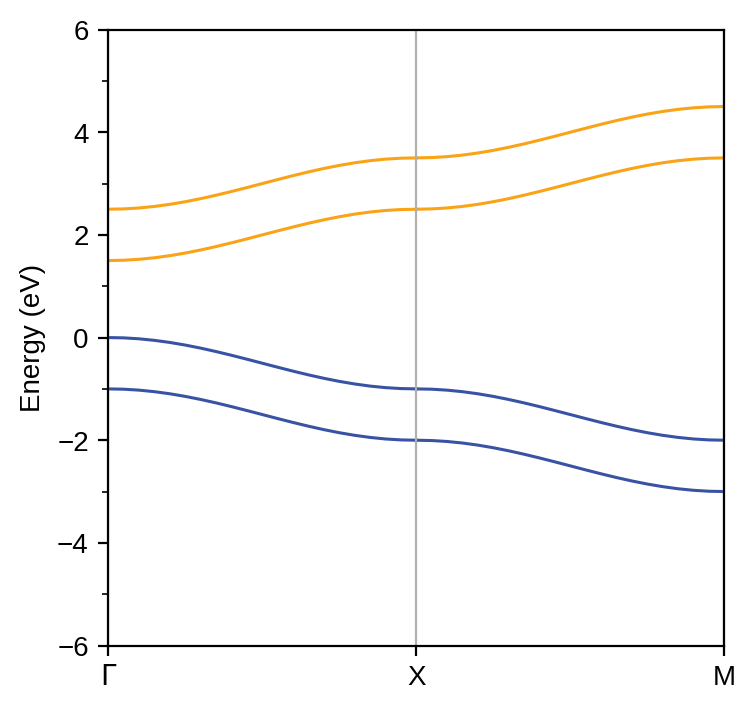

In [8]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=200)
_ = band_structure.plot_band_structure(bs, plt, ymin=-6, ymax=6)

4) Extract the band gap and report it

In [9]:
fundamental_gap = bs.get_band_gap()
E_gap_fundamental = fundamental_gap["energy"]
E_gap_direct = bs.get_direct_band_gap()
print(f"Band Gap = {E_gap_fundamental:.2f} eV, {fundamental_gap['transition']}")

Band Gap = 1.50 eV, \Gamma-\Gamma
